# cavapy: Pakistan climate-data introduction

This practical shows how **cavapy** retrieves a small spatial slice from ERA5 and CORDEX-CORE, returns an analysis-ready `xarray.DataArray`, and leaves the next analytical step transparent. The worked example uses maximum temperature in Pakistan.



## 1. Create the shared Mamba environment

Run these commands in a terminal. The same environment supports both training notebooks.

```bash
mamba create -n cavapk -c conda-forge \
  python=3.12 r-base=4.5 \
  r-rjava r-pak r-terra r-units r-remotes \
  jupyterlab ipykernel r-irkernel

mamba activate cavapk
R -q -e 'remotes::install_github("un-fao/CAVAanalytics")'
python -m pip install cavapy
```



## 2. Define the Pakistan request

Pakistan is covered by **WAS-22**. We first request a short ERA5 sample, then one bias-corrected MPI–REMO projection to keep the live demonstration fast and the return structure easy to inspect.


In [1]:
import cavapy

COUNTRY = "Pakistan"
DOMAIN = "WAS-22"
VARIABLE = "tasmax"
OBS_YEARS = range(1991, 1996)
BASELINE = (1991, 2000)
FUTURE = (2021, 2030)


## 3. Retrieve a short ERA5 sample

The slow cell streams only the grid cells intersecting Pakistan. Using one variable and `num_processes=1` avoids multiprocessing surprises during a live notebook session.


In [2]:
obs_data = cavapy.get_climate_data(
            country=COUNTRY,
            variables=[VARIABLE],
            obs=True,
            years_obs=OBS_YEARS,
            num_processes=1,
        )

10:42:32 [INFO] climate.URL-validation-ERA5-tasmax: https://hub.ipcc.ifca.es/thredds/dodsC/fao/observations/ERA5/0.25/ERA5_025.ncml
INFO:climate.URL-validation-ERA5-tasmax:https://hub.ipcc.ifca.es/thredds/dodsC/fao/observations/ERA5/0.25/ERA5_025.ncml
10:42:33 [INFO] climate.ERA5-tasmax: Connection established
INFO:climate.ERA5-tasmax:Connection established
10:43:34 [INFO] climate.ERA5-tasmax: ERA5 data for tasmax has been processed: unit conversion (°C), time selection (1991-1995)
INFO:climate.ERA5-tasmax:ERA5 data for tasmax has been processed: unit conversion (°C), time selection (1991-1995)


In [3]:
tasmax_obs = obs_data[VARIABLE]
print(tasmax_obs)
print("Dimensions:", dict(tasmax_obs.sizes))
print("Date range:", tasmax_obs.time.min().values, "to", tasmax_obs.time.max().values)
print("Units:", tasmax_obs.attrs.get("units", "not reported"))



<xarray.DataArray 't2mx' (time: 1826, latitude: 53, longitude: 65)> Size: 25MB
array([[[  1.214386  ,  -0.9117737 ,  -2.9664612 , ..., -23.328598  ,
         -21.623474  , -18.275864  ],
        [  1.7398071 ,   0.19760132,  -1.9469299 , ..., -30.24823   ,
         -28.944946  , -26.28563   ],
        [  2.4983826 ,   0.56674194,  -1.2731018 , ..., -33.386566  ,
         -32.88852   , -30.814087  ],
        ...,
        [ 21.519531  ,  21.383514  ,  21.346283  , ...,  17.32846   ,
          17.400726  ,  17.523773  ],
        [ 21.726562  ,  21.535156  ,  21.254486  , ...,  17.375336  ,
          17.39682   ,  17.457367  ],
        [ 21.732513  ,  21.601654  ,  21.553314  , ...,  17.904633  ,
          17.806976  ,  17.574554  ]],

       [[  3.1446228 ,   1.0411072 ,  -0.8404236 , ..., -25.441147  ,
         -23.91771   , -18.490067  ],
        [  4.5450134 ,   1.3184509 ,  -0.6158142 , ..., -31.740067  ,
         -29.997879  , -26.42952   ],
        [  4.912201  ,   1.3946228 ,  -0.7

## 4. Make a spatial map and annual time series

The plotting helpers work directly with the returned DataArray. For maximum temperature, spatial and annual means provide an intuitive first look.


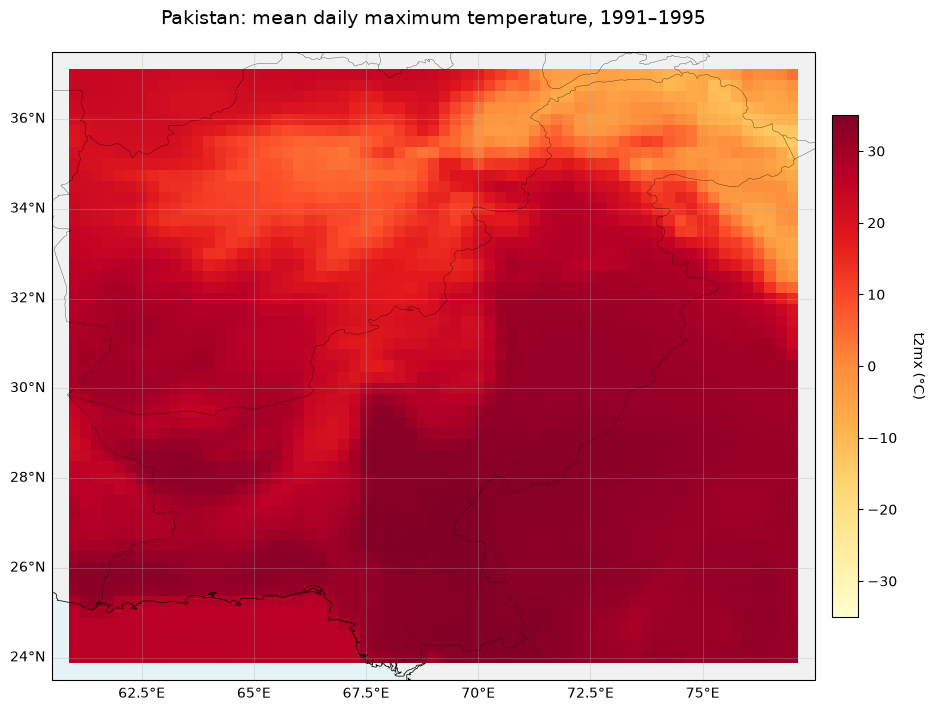

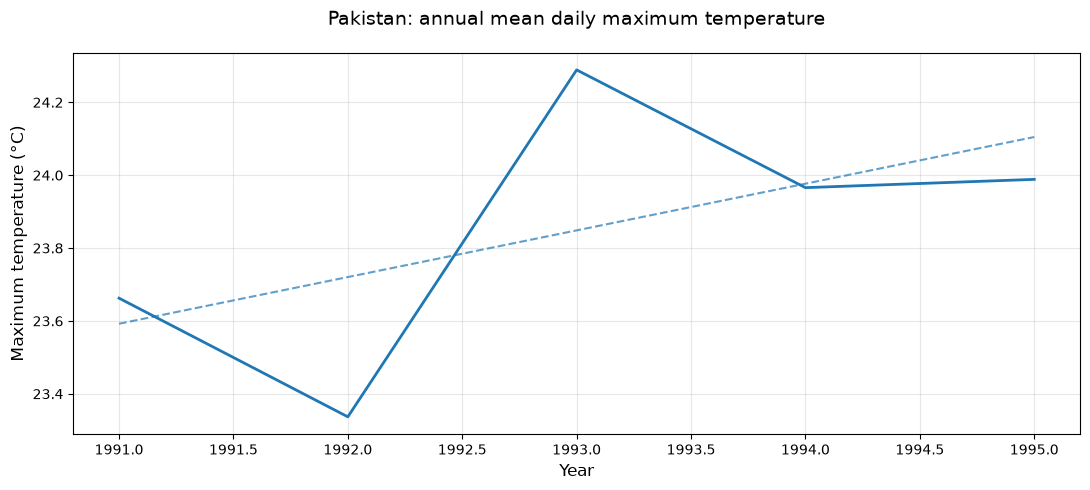

In [5]:

fig_map = cavapy.plot_spatial_map(
        tasmax_obs,
        time_period=(1991, 1995),
        aggregation="mean",
        title="Pakistan: mean daily maximum temperature, 1991–1995",
        cmap="YlOrRd",
        figsize=(10, 7),
    )

fig_ts = cavapy.plot_time_series(
    tasmax_obs,
    aggregation="mean",
    title="Pakistan: annual mean daily maximum temperature",
    ylabel="Maximum temperature (°C)",
    trend_line=True,
    figsize=(11, 5),
)


## 5. Retrieve one historical-plus-projection series

`CORDEX-CORE-BC` is already bias-corrected using the ISIMIP methodology. Do not combine it with `bias_correction=True`.


In [ ]:

projection_data = cavapy.get_climate_data(
            country=COUNTRY,
            variables=[VARIABLE],
            cordex_domain=DOMAIN,
            rcp="rcp85",
            gcm="MPI",
            rcm="REMO",
            years_up_to=2030,
            historical=True,
            dataset="CORDEX-CORE-BC",
            bias_correction=False,
        )

10:39:31 [INFO] climate.URL-validation-MPI-REMO-historical: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MPI-M-MPI-ESM-LR/historical/r1i1p1/REMO2015/v1/day/CORDEX_output_WAS-22_GERICS_MPI-M-MPI-ESM-LR_historical_r1i1p1_REMO2015_v1_day.ncml
INFO:climate.URL-validation-MPI-REMO-historical:https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MPI-M-MPI-ESM-LR/historical/r1i1p1/REMO2015/v1/day/CORDEX_output_WAS-22_GERICS_MPI-M-MPI-ESM-LR_historical_r1i1p1_REMO2015_v1_day.ncml
10:39:31 [INFO] climate.URL-validation-MPI-REMO-rcp85: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MPI-M-MPI-ESM-LR/rcp85/r1i1p1/REMO2015/v1/day/CORDEX_output_WAS-22_GERICS_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_REMO2015_v1_day.ncml
INFO:climate.URL-validation-MPI-REMO-rcp85:https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MPI-M-MPI-ESM-L

## 6. Optional extensions

### Add precipitation

Request `variables=["tasmax", "pr"]`. 

### Request a multi-model ensemble

Pass lists—or `None` for all available values—to `rcp`, `gcm`, and `rcm`. The return structure becomes:



In [7]:
multi = cavapy.get_climate_data(
        country=COUNTRY,
        variables=[VARIABLE],
        cordex_domain=DOMAIN,
        rcp=None,
        gcm=None,
        rcm="REMO",
        years_up_to=2030,
        historical=True,
        dataset="CORDEX-CORE-BC",
    )

12:09:22 [INFO] climate.URL-validation-MOHC-REMO-historical: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MOHC-HadGEM2-ES/historical/r1i1p1/REMO2015/v1/day/CORDEX_output_WAS-22_GERICS_MOHC-HadGEM2-ES_historical_r1i1p1_REMO2015_v1_day.ncml
INFO:climate.URL-validation-MOHC-REMO-historical:https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MOHC-HadGEM2-ES/historical/r1i1p1/REMO2015/v1/day/CORDEX_output_WAS-22_GERICS_MOHC-HadGEM2-ES_historical_r1i1p1_REMO2015_v1_day.ncml
12:09:22 [INFO] climate.URL-validation-MOHC-REMO-rcp26: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MOHC-HadGEM2-ES/rcp26/r1i1p1/REMO2015/v1/day/CORDEX_output_WAS-22_GERICS_MOHC-HadGEM2-ES_rcp26_r1i1p1_REMO2015_v1_day.ncml
INFO:climate.URL-validation-MOHC-REMO-rcp26:https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/WAS-22/GERICS/MOHC-HadGEM2-ES/r

KeyboardInterrupt: 

## Takeaway

cavapy is the stronger route when the immediate goal is efficient climate-data access in Python, scalable retrieval, and direct integration with the broader `xarray`/Dask ecosystem. Use CAVAanalytics when you want its higher-level indicator, ensemble, and mapping workflow.
